# CXCR4 Binding-Pocket Analysis

This notebook will download, from RCSB PDB, two determined CXCR4 structures bound to antagonists the paper titled: "Structures of the CXCR4 chemokine GPCR with small-molecule and cyclic peptide antagonists". These ligand-protein complexes are the following:

- 3ODU: CXCR4 bound to IT1t 
- 3OE0: CXCR4 bound CVX15 

The goal of this project is to identify CXCR4 residues located near each antagonist and compare their binding footprints. 

In [1]:
from pathlib import Path
import requests 

In [2]:
PDB_IDS = ["3ODU", "3OE0"]

DATA_DIR = Path("Data")

DATA_DIR.mkdir(exist_ok=True)

print("Structures:", PDB_IDS)

print("Data directory:", DATA_DIR)

Structures: ['3ODU', '3OE0']
Data directory: Data


In [3]:
def download_pdb(pdb_id):
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    output_path = DATA_DIR / f"{pdb_id}.pdb"

    if output_path.exists():
        print(f"{output_path} already exists. Skipping download.")
        return output_path

    print(f"Downloading {pdb_id}")
    print(f"URL: {url}")

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    output_path.write_text(response.text)

    print(f"Saved {pdb_id} to {output_path}")
    return output_path

In [4]:
for pdb_id in PDB_IDS:
    downloaded_file = download_pdb(pdb_id)
    print(f"Finished processing: {downloaded_file}")

Data\3ODU.pdb already exists. Skipping download.
Finished processing: Data\3ODU.pdb
Data\3OE0.pdb already exists. Skipping download.
Finished processing: Data\3OE0.pdb


In [5]:
for pdb_id in PDB_IDS:
    pdb_path = DATA_DIR / f"{pdb_id}.pdb"

    print(f"PDB ID: {pdb_id}")
    print(f"Path: {pdb_path}")
    print(f"Exists: {pdb_path.exists()}")
    print(f"Size: {pdb_path.stat().st_size} bytes")
    print()

PDB ID: 3ODU
Path: Data\3ODU.pdb
Exists: True
Size: 1342586 bytes

PDB ID: 3OE0
Path: Data\3OE0.pdb
Exists: True
Size: 643864 bytes



In [6]:
pdb_path = DATA_DIR / "3ODU.pdb"

with pdb_path.open("r") as pdb_file:
    for line_number in range(5):
        line = pdb_file.readline()
        print(line.rstrip())

HEADER    SIGNALING PROTEIN, HYDROLASE            11-AUG-10   3ODU
TITLE     THE 2.5 A STRUCTURE OF THE CXCR4 CHEMOKINE RECEPTOR IN COMPLEX WITH
TITLE    2 SMALL MOLECULE ANTAGONIST IT1T
COMPND    MOL_ID: 1;
COMPND   2 MOLECULE: C-X-C CHEMOKINE RECEPTOR TYPE 4, LYSOZYME CHIMERA;


In [7]:
for pdb_id in PDB_IDS:
    pdb_path = DATA_DIR / f"{pdb_id}.pdb"

    print("=" * 70)
    print(f"STRUCTURE: {pdb_id}")
    print("=" * 70)

    with pdb_path.open("r") as pdb_file:
        for line_number in range(10):
            line = pdb_file.readline()
            print(line.rstrip())

    print()

STRUCTURE: 3ODU
HEADER    SIGNALING PROTEIN, HYDROLASE            11-AUG-10   3ODU
TITLE     THE 2.5 A STRUCTURE OF THE CXCR4 CHEMOKINE RECEPTOR IN COMPLEX WITH
TITLE    2 SMALL MOLECULE ANTAGONIST IT1T
COMPND    MOL_ID: 1;
COMPND   2 MOLECULE: C-X-C CHEMOKINE RECEPTOR TYPE 4, LYSOZYME CHIMERA;
COMPND   3 CHAIN: A, B;
COMPND   4 FRAGMENT: CXCR4 RESIDUES 2-229, LYSOZYME RESIDUES 1002-1161, CXCR4
COMPND   5 RESIDUES 230-319;
COMPND   6 SYNONYM: CXC-R4, CXCR-4, STROMAL CELL-DERIVED FACTOR 1 RECEPTOR, SDF-
COMPND   7 1 RECEPTOR, FUSIN, LEUKOCYTE-DERIVED SEVEN TRANSMEMBRANE DOMAIN

STRUCTURE: 3OE0
HEADER    SIGNALING PROTEIN, HYDROLASE/ANTIBIOTIC 12-AUG-10   3OE0
TITLE     CRYSTAL STRUCTURE OF THE CXCR4 CHEMOKINE RECEPTOR IN COMPLEX WITH A
TITLE    2 CYCLIC PEPTIDE ANTAGONIST CVX15
COMPND    MOL_ID: 1;
COMPND   2 MOLECULE: C-X-C CHEMOKINE RECEPTOR TYPE 4, LYSOZYME CHIMERA;
COMPND   3 CHAIN: A;
COMPND   4 FRAGMENT: CXCR4 RESIDUES 2-228, LYSOZYME RESIDUES 1002-1161, CXCR4
COMPND   5 RESIDUES 

In [8]:
from Bio.PDB import PDBParser

print("Biopython PDBParser imported successfully")

Biopython PDBParser imported successfully


In [9]:
parser = PDBParser(QUIET=True)

print(parser)

In [10]:
structure_3odu = parser.get_structure("3ODU", DATA_DIR / "3ODU.pdb")

print(structure_3odu)

<Structure id=3ODU>


In [11]:
structure_3oe0 = parser.get_structure("3OE0", DATA_DIR / "3OE0.pdb")

print(structure_3oe0)

<Structure id=3OE0>


In [12]:
for structure in [structure_3odu, structure_3oe0]:
    print(f"Structure: {structure.id}")

    for model in structure:
        print(f"  Model ID: {model.id}")

Structure: 3ODU
  Model ID: 0
Structure: 3OE0
  Model ID: 0


In [13]:
for structure in [structure_3odu, structure_3oe0]:
    print(f"\nStructure: {structure.id}")

    model = structure[0]

    for chain in model:
        residues = list(chain.get_residues())

        print(f"Chain {chain.id}: "f"{len(residues)} residues")


Structure: 3ODU
Chain A: 544 residues
Chain B: 533 residues

Structure: 3OE0
Chain A: 436 residues
Chain I: 19 residues


In [14]:
model_3odu = structure_3odu[0]
chain_a_3odu = model_3odu["A"]

for residue in list(chain_a_3odu.get_residues())[:10]:
    print("Residue name:", residue.resname, "| Residue ID:", residue.id)

Residue name: PRO | Residue ID: (' ', 27, ' ')
Residue name: CYS | Residue ID: (' ', 28, ' ')
Residue name: PHE | Residue ID: (' ', 29, ' ')
Residue name: ARG | Residue ID: (' ', 30, ' ')
Residue name: GLU | Residue ID: (' ', 31, ' ')
Residue name: GLU | Residue ID: (' ', 32, ' ')
Residue name: ASN | Residue ID: (' ', 33, ' ')
Residue name: ALA | Residue ID: (' ', 34, ' ')
Residue name: ASN | Residue ID: (' ', 35, ' ')
Residue name: PHE | Residue ID: (' ', 36, ' ')


## Select the IT1t ligand from 3ODU

IT1t is represented by the PDB residue name ITD. Due to 3ODU containing receptor copies in chains A and B, this analysis uses the IT1t molecule associated with chain A.

In [15]:
it1t_residues = [residue for chain in structure_3odu[0] for residue in chain if residue.resname == "ITD"]

print("Number of IT1t residues found:", len(it1t_residues))

Number of IT1t residues found: 2


In [16]:
for residue in it1t_residues:
    print(residue.get_parent().id, residue.resname, residue.id, len(list(residue.get_atoms())))

A ITD ('H_ITD', 1500, ' ') 27
B ITD ('H_ITD', 1500, ' ') 27


In [17]:
it1t_atoms = [atom for residue in structure_3odu[0]["A"] if residue.resname == "ITD" for atom in residue.get_atoms()]

print("Number of IT1t atoms selected from chain A:", len(it1t_atoms))

Number of IT1t atoms selected from chain A: 27


## Select the CVX15 peptide from 3OE0

CVX15 is represented as peptide chain I rather than as one chemical residue. Chain I also contains crystallographic water molecules, so only peptide residues 1 through 16 are included.

In [18]:
chain_ids_3oe0 = [chain.id for chain in structure_3oe0[0]]

print("Chains in 3OE0:", chain_ids_3oe0)

Chains in 3OE0: ['A', 'I']


In [19]:
cvx15_chain = structure_3oe0[0]["I"]

print("Selected chain:", cvx15_chain.id)

Selected chain: I


In [20]:
cvx15_residues = list(cvx15_chain.get_residues())

print("Number of residues in chain I:", len(cvx15_residues))

Number of residues in chain I: 19


In [21]:
cvx15_residue_names = [residue.resname for residue in cvx15_residues]

print("CVX15 residue names:")
print(cvx15_residue_names)

CVX15 residue names:
['ARG', 'ARG', 'ALN', 'CYS', 'TYR', 'GLN', 'LYS', 'DPR', 'PRO', 'TYR', 'ARG', 'CIR', 'CYS', 'ARG', 'GLY', 'DPR', 'HOH', 'HOH', 'HOH']


In [22]:
cvx15_labels = [f"{residue.resname}{residue.id[1]}" for residue in cvx15_residues]

print("CVX15 residue labels:")
print(cvx15_labels)

CVX15 residue labels:
['ARG1', 'ARG2', 'ALN3', 'CYS4', 'TYR5', 'GLN6', 'LYS7', 'DPR8', 'PRO9', 'TYR10', 'ARG11', 'CIR12', 'CYS13', 'ARG14', 'GLY15', 'DPR16', 'HOH1601', 'HOH1602', 'HOH1604']


In [23]:
cvx15_peptide_residues = [residue for residue in cvx15_chain if 1 <= residue.id[1] <= 16]

cvx15_atoms = [atom for residue in cvx15_peptide_residues for atom in residue.get_atoms()]

print("CVX15 peptide residues:", len(cvx15_peptide_residues))
print("CVX15 atoms excluding water:", len(cvx15_atoms))

CVX15 peptide residues: 16
CVX15 atoms excluding water: 150


## Select CXCR4 receptor residues

Chain A contains the engineered CXCR4-T4 lysozyme crystallization construct. Standard polymer residues numbered 2 through 319 are retained as CXCR4, while high-numbered lysozyme residues and hetero-components are excluded.

In [24]:
chain_a_3odu = structure_3odu[0]["A"]
chain_a_3oe0 = structure_3oe0[0]["A"]

print("3ODU receptor chain:", chain_a_3odu.id)
print("3OE0 receptor chain:", chain_a_3oe0.id)

3ODU receptor chain: A
3OE0 receptor chain: A


In [25]:
residue_numbers_3odu = [residue.id[1]
    for residue in chain_a_3odu]

residue_numbers_3oe0 = [residue.id[1]
    for residue in chain_a_3oe0]

print("3ODU minimum residue number:", min(residue_numbers_3odu))
print("3ODU maximum residue number:", max(residue_numbers_3odu))

print("3OE0 minimum residue number:", min(residue_numbers_3oe0))
print("3OE0 maximum residue number:", max(residue_numbers_3oe0))

3ODU minimum residue number: 27
3ODU maximum residue number: 1758
3OE0 minimum residue number: 25
3OE0 maximum residue number: 1605


In [26]:
cxcr4_residues_3odu = [residue for residue in chain_a_3odu if residue.id[0] == " " and 2 <= residue.id[1] <= 319]

print("CXCR4 residues selected from 3ODU:", len(cxcr4_residues_3odu))

CXCR4 residues selected from 3ODU: 293


In [27]:
cxcr4_residues_3oe0 = [residue for residue in chain_a_3oe0 if residue.id[0] == " " and 2 <= residue.id[1] <= 319]

print("CXCR4 residues selected from 3OE0:", len(cxcr4_residues_3oe0))

CXCR4 residues selected from 3OE0: 273


In [28]:
print("Any 3ODU selected residues above 319:", any(residue.id[1] > 319 for residue in cxcr4_residues_3odu))

print("Any 3OE0 selected residues above 319:", any(residue.id[1] > 319 for residue in cxcr4_residues_3oe0))

Any 3ODU selected residues above 319: False
Any 3OE0 selected residues above 319: False


In [29]:
cxcr4_atoms_3odu = [atom for residue in cxcr4_residues_3odu for atom in residue.get_atoms()]

In [30]:
cxcr4_atoms_3oe0 = [atom for residue in cxcr4_residues_3oe0 for atom in residue.get_atoms()]

In [31]:
it1t_atoms = [atom for residue in structure_3odu[0]["A"] if residue.resname == "ITD" for atom in residue.get_atoms()]

In [32]:
cvx15_atoms = [atom for residue in structure_3oe0[0]["I"] if 1 <= residue.id[1] <= 16 for atom in residue.get_atoms()]

In [33]:
print("3ODU CXCR4 atoms:", len(cxcr4_atoms_3odu))
print("IT1t atoms:", len(it1t_atoms))
print("3OE0 CXCR4 atoms:", len(cxcr4_atoms_3oe0))
print("CVX15 atoms:", len(cvx15_atoms))

3ODU CXCR4 atoms: 2371
IT1t atoms: 27
3OE0 CXCR4 atoms: 2209
CVX15 atoms: 150


In [34]:
print("STRUCTURAL SELECTION CHECKPOINT")
print("--------------------------------")

print("3ODU CXCR4 residues:", len(cxcr4_residues_3odu))
print("3ODU CXCR4 atoms:", len(cxcr4_atoms_3odu))
print("3ODU IT1t atoms:", len(it1t_atoms))

print()

print("3OE0 CXCR4 residues:", len(cxcr4_residues_3oe0))
print("3OE0 CXCR4 atoms:", len(cxcr4_atoms_3oe0))
print("3OE0 CVX15 residues:", len(cvx15_peptide_residues))
print("3OE0 CVX15 atoms:", len(cvx15_atoms))

STRUCTURAL SELECTION CHECKPOINT
--------------------------------
3ODU CXCR4 residues: 293
3ODU CXCR4 atoms: 2371
3ODU IT1t atoms: 27

3OE0 CXCR4 residues: 273
3OE0 CXCR4 atoms: 2209
3OE0 CVX15 residues: 16
3OE0 CVX15 atoms: 150


In [35]:
assert len(cxcr4_atoms_3odu) > 0, "No 3ODU CXCR4 atoms were selected"
assert len(it1t_atoms) > 0, "No IT1t atoms were selected"
assert len(cxcr4_atoms_3oe0) > 0, "No 3OE0 CXCR4 atoms were selected"
assert len(cvx15_atoms) > 0, "No CVX15 atoms were selected"

print("All four atom selections passed.")

All four atom selections passed.


## Identify ligand-contacting CXCR4 residues

A CXCR4 residue will be classified as a contact when at least one of its
atoms lies within 4.5 Å of at least one ligand atom.

This is a geometric proximity criterion. It identifies residues surrounding
the ligand but does not, by itself, classify the chemical interaction or
estimate binding affinity.

In [36]:
from Bio.PDB import NeighborSearch

print("NeighborSearch imported successfully")

NeighborSearch imported successfully


In [37]:
DISTANCE_CUTOFF = 4.5

print("Contact cutoff:", DISTANCE_CUTOFF, "angstroms")

Contact cutoff: 4.5 angstroms


In [38]:
neighbor_search_3odu = NeighborSearch(cxcr4_atoms_3odu)

print("3ODU NeighborSearch object created")

3ODU NeighborSearch object created


In [39]:
first_it1t_atom = it1t_atoms[0]

print("Atom name:", first_it1t_atom.name)
print("Element:", first_it1t_atom.element)
print("Coordinates:", first_it1t_atom.coord)

Atom name: C1
Element: C
Coordinates: [16.263 -6.28  67.102]


In [40]:
nearby_residues = neighbor_search_3odu.search(first_it1t_atom.coord, DISTANCE_CUTOFF, level="R")

print("Number of CXCR4 residues near the first IT1t atom:", len(nearby_residues))

Number of CXCR4 residues near the first IT1t atom: 2


In [41]:
nearby_labels = [f"{residue.resname}{residue.id[1]}" for residue in nearby_residues]

print("Residues near the first IT1t atom:")
print(nearby_labels)

Residues near the first IT1t atom:
['GLU288', 'TYR116']


In [42]:
def find_contact_residues(receptor_atoms, ligand_atoms, cutoff):
    neighbor_search = NeighborSearch(receptor_atoms)
    contact_residues = set()

    for ligand_atom in ligand_atoms:
        nearby_residues = neighbor_search.search(ligand_atom.coord, cutoff, level="R")

        contact_residues.update(nearby_residues)

    return contact_residues

In [43]:
it1t_contact_residues = find_contact_residues(cxcr4_atoms_3odu, it1t_atoms, DISTANCE_CUTOFF)

print("CXCR4 residues within 4.5 Å of IT1t:", len(it1t_contact_residues))

CXCR4 residues within 4.5 Å of IT1t: 14


In [44]:
cvx15_contact_residues = find_contact_residues(cxcr4_atoms_3oe0, cvx15_atoms, DISTANCE_CUTOFF)

print("CXCR4 residues within 4.5 Å of CVX15:", len(cvx15_contact_residues))

CXCR4 residues within 4.5 Å of CVX15: 30


In [45]:
it1t_contacts = [(residue.resname, residue.id[1]) for residue in it1t_contact_residues]

cvx15_contacts = [(residue.resname, residue.id[1]) for residue in cvx15_contact_residues]

In [46]:
it1t_contacts = sorted(it1t_contacts, key=lambda contact: contact[1])

cvx15_contacts = sorted(cvx15_contacts, key=lambda contact: contact[1])

In [47]:
it1t_contact_labels = [f"{name}{number}" for name, number in it1t_contacts]

cvx15_contact_labels = [f"{name}{number}" for name, number in cvx15_contacts]

print("IT1t-contacting CXCR4 residues:")
print(it1t_contact_labels)

print()

print("CVX15-contacting CXCR4 residues:")
print(cvx15_contact_labels)

IT1t-contacting CXCR4 residues:
['GLU32', 'TRP94', 'ASP97', 'ALA98', 'TRP102', 'VAL112', 'HIS113', 'TYR116', 'ARG183', 'ILE185', 'CYS186', 'ASP187', 'ARG188', 'GLU288']

CVX15-contacting CXCR4 residues:
['GLU26', 'PRO27', 'GLU32', 'HIS113', 'TYR116', 'THR117', 'ASP171', 'SER178', 'ILE185', 'CYS186', 'ASP187', 'ARG188', 'PHE189', 'TYR190', 'PRO191', 'ASN192', 'ASP193', 'VAL196', 'PHE199', 'GLN200', 'HIS203', 'TYR255', 'ASP262', 'ILE265', 'LEU266', 'GLU277', 'HIS281', 'ILE284', 'SER285', 'GLU288']


In [48]:
print("CONTACT ANALYSIS CHECKPOINT")
print("---------------------------")

print("IT1t contact count:", len(it1t_contact_labels))
print("IT1t contacts:")
print(it1t_contact_labels)

print()

print("CVX15 contact count:", len(cvx15_contact_labels))
print("CVX15 contacts:")
print(cvx15_contact_labels)

CONTACT ANALYSIS CHECKPOINT
---------------------------
IT1t contact count: 14
IT1t contacts:
['GLU32', 'TRP94', 'ASP97', 'ALA98', 'TRP102', 'VAL112', 'HIS113', 'TYR116', 'ARG183', 'ILE185', 'CYS186', 'ASP187', 'ARG188', 'GLU288']

CVX15 contact count: 30
CVX15 contacts:
['GLU26', 'PRO27', 'GLU32', 'HIS113', 'TYR116', 'THR117', 'ASP171', 'SER178', 'ILE185', 'CYS186', 'ASP187', 'ARG188', 'PHE189', 'TYR190', 'PRO191', 'ASN192', 'ASP193', 'VAL196', 'PHE199', 'GLN200', 'HIS203', 'TYR255', 'ASP262', 'ILE265', 'LEU266', 'GLU277', 'HIS281', 'ILE284', 'SER285', 'GLU288']


## Compare the antagonist contact footprints

The two contact sets are compared to identify:

- Shared CXCR4 contacts
- Contacts detected only for IT1t
- Contacts detected only for CVX15

In [49]:
it1t_contact_set = set(it1t_contacts)
cvx15_contact_set = set(cvx15_contacts)

print("IT1t unique contacts:", len(it1t_contact_set))
print("CVX15 unique contacts:", len(cvx15_contact_set))

IT1t unique contacts: 14
CVX15 unique contacts: 30


In [50]:
shared_contacts = it1t_contact_set & cvx15_contact_set
it1t_only_contacts = it1t_contact_set - cvx15_contact_set
cvx15_only_contacts = cvx15_contact_set - it1t_contact_set
all_contacts = it1t_contact_set | cvx15_contact_set

In [51]:
print("Shared contacts:", len(shared_contacts))
print("IT1t-only contacts:", len(it1t_only_contacts))
print("CVX15-only contacts:", len(cvx15_only_contacts))
print("All unique contacts:", len(all_contacts))

Shared contacts: 8
IT1t-only contacts: 6
CVX15-only contacts: 22
All unique contacts: 36


In [52]:
assert len(shared_contacts) + len(it1t_only_contacts) == len(it1t_contact_set)
assert len(shared_contacts) + len(cvx15_only_contacts) == len(cvx15_contact_set)

print("Set-comparison checks passed.")

Set-comparison checks passed.


In [53]:
def sort_contacts(contact_set):
    return sorted(contact_set, key=lambda contact: contact[1])

In [54]:
shared_sorted = sort_contacts(shared_contacts)
it1t_only_sorted = sort_contacts(it1t_only_contacts)
cvx15_only_sorted = sort_contacts(cvx15_only_contacts)

In [55]:
def format_contacts(contact_list):
    return [f"{residue_name}{residue_number}" for residue_name, residue_number in contact_list]

In [56]:
shared_labels = format_contacts(shared_sorted)
it1t_only_labels = format_contacts(it1t_only_sorted)
cvx15_only_labels = format_contacts(cvx15_only_sorted)

In [57]:
print("SHARED CXCR4 CONTACTS")
print("---------------------")
print(shared_labels)

print()

print("IT1t-ONLY CXCR4 CONTACTS")
print("------------------------")
print(it1t_only_labels)

print()

print("CVX15-ONLY CXCR4 CONTACTS")
print("-------------------------")
print(cvx15_only_labels)

SHARED CXCR4 CONTACTS
---------------------
['GLU32', 'HIS113', 'TYR116', 'ILE185', 'CYS186', 'ASP187', 'ARG188', 'GLU288']

IT1t-ONLY CXCR4 CONTACTS
------------------------
['TRP94', 'ASP97', 'ALA98', 'TRP102', 'VAL112', 'ARG183']

CVX15-ONLY CXCR4 CONTACTS
-------------------------
['GLU26', 'PRO27', 'THR117', 'ASP171', 'SER178', 'PHE189', 'TYR190', 'PRO191', 'ASN192', 'ASP193', 'VAL196', 'PHE199', 'GLN200', 'HIS203', 'TYR255', 'ASP262', 'ILE265', 'LEU266', 'GLU277', 'HIS281', 'ILE284', 'SER285']


In [58]:
import matplotlib.pyplot as plt 
from pathlib import Path

RESULTS_DIR = Path("Results")
RESULTS_DIR.mkdir(exist_ok=True)

print("Results folder:", RESULTS_DIR)

Results folder: Results


In [59]:
categories = ["Shared", "IT1t only", "CVX15 only"]

contact_counts = [len(shared_contacts), len(it1t_only_contacts), len(cvx15_only_contacts)]

print(categories)
print(contact_counts)

['Shared', 'IT1t only', 'CVX15 only']
[8, 6, 22]


High Resolution Graph saved to: Results\High_Resolution_Cxcr4_Contact_Comparison_Graph.png
Preview Graph saved to: Results\Preview_Cxcr4_Contact_Comparison_Graph.png


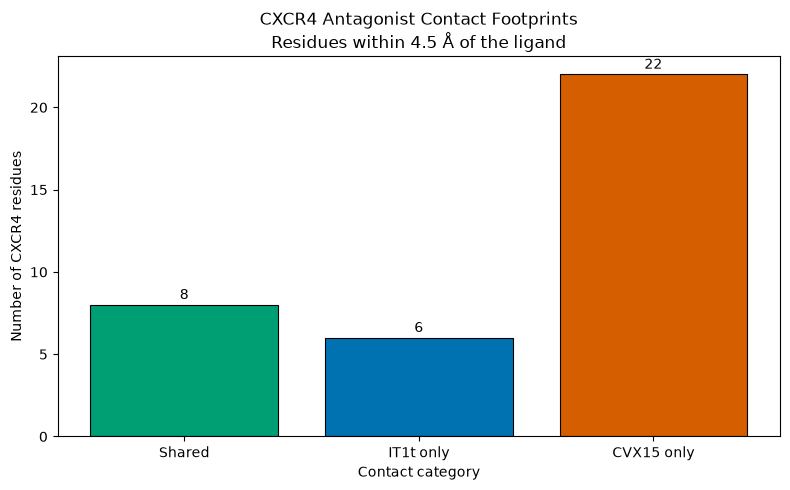

In [60]:
fig, ax = plt.subplots(figsize=(8, 5))

colorblind_colors = ["#009E73", "#0072B2", "#D55E00"]

bars = ax.bar(categories, contact_counts, color=colorblind_colors, edgecolor="black", linewidth=0.8)

ax.set_ylabel("Number of CXCR4 residues")
ax.set_xlabel("Contact category")
ax.set_title("CXCR4 Antagonist Contact Footprints\n""Residues within 4.5 Å of the ligand")

for bar, count in zip(bars, contact_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15, str(count), ha="center", va="bottom")

plt.tight_layout()

figure_path = RESULTS_DIR / "High_Resolution_Cxcr4_Contact_Comparison_Graph.png"

fig.savefig(figure_path, dpi=300, bbox_inches= "tight")

preview_path = RESULTS_DIR / "Preview_Cxcr4_Contact_Comparison_Graph.png"

fig.savefig(preview_path, dpi=120, bbox_inches= "tight")

print("High Resolution Graph saved to:", figure_path)
print("Preview Graph saved to:", preview_path)

plt.show()

In [61]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [62]:
import pandas as pd

In [63]:
comparison_rows = []

for residue_name, residue_number in sorted(all_contacts, key=lambda contact: contact[1]):
    in_it1t = (residue_name, residue_number) in it1t_contact_set
    in_cvx15 = (residue_name, residue_number) in cvx15_contact_set

    if in_it1t and in_cvx15:
        category = "Shared"
    elif in_it1t:
        category = "IT1t only"
    else:
        category = "CVX15 only"

    comparison_rows.append({"Residue name": residue_name, "Residue number": residue_number, "Residue label": f"{residue_name}{residue_number}", "IT1t contact": in_it1t, "CVX15 contact": in_cvx15, "Category": category})

contact_table = pd.DataFrame(comparison_rows)

contact_table

,Residue name,Residue number,Residue label,IT1t contact,CVX15 contact,Category
0,GLU,26,GLU26,False,True,CVX15 only
1,PRO,27,PRO27,False,True,CVX15 only
2,GLU,32,GLU32,True,True,Shared
3,TRP,94,TRP94,True,False,IT1t only
4,ASP,97,ASP97,True,False,IT1t only
5,ALA,98,ALA98,True,False,IT1t only
6,TRP,102,TRP102,True,False,IT1t only
7,VAL,112,VAL112,True,False,IT1t only
8,HIS,113,HIS113,True,True,Shared
9,TYR,116,TYR116,True,True,Shared


In [64]:
csv_path = RESULTS_DIR / "Cxcr4_Contact_Residues.csv"

contact_table.to_csv(csv_path, index=False)

print("Contact table saved to:", csv_path)

Contact table saved to: Results\Cxcr4_Contact_Residues.csv


In [65]:
print("Chart exists:", figure_path.exists())
print("CSV exists:", csv_path.exists())

print("Chart size:", figure_path.stat().st_size, "bytes")
print("CSV size:", csv_path.stat().st_size, "bytes")

Chart exists: True
CSV exists: True
Chart size: 84219 bytes
CSV size: 1389 bytes


## Cutoff-sensitivity analysis

Due to the definition of a contact depends on the selected distance threshold, the analysis is repeated with cutoffs from 3.5 to 5.0 Å. This tests whether the overall comparison is robust to reasonable changes in the contact definition.

In [66]:
test_cutoffs = [3.5, 4.0, 4.5, 5.0]

sensitivity_results = []

for cutoff in test_cutoffs:
    it1t_test = find_contact_residues(cxcr4_atoms_3odu, it1t_atoms, cutoff)

    cvx15_test = find_contact_residues(cxcr4_atoms_3oe0, cvx15_atoms,cutoff)

    it1t_test_set = {(residue.resname, residue.id[1])
        for residue in it1t_test}

    cvx15_test_set = {(residue.resname, residue.id[1])
        for residue in cvx15_test}

    sensitivity_results.append({"Cutoff (Å)": cutoff, "IT1t contacts": len(it1t_test_set), "CVX15 contacts": len(cvx15_test_set),"Shared contacts": len(it1t_test_set & cvx15_test_set)})

sensitivity_table = pd.DataFrame(sensitivity_results)

sensitivity_table

,Cutoff (Å),IT1t contacts,CVX15 contacts,Shared contacts
0,3.5,3,15,0
1,4.0,12,26,5
2,4.5,14,30,8
3,5.0,16,33,9


In [67]:
assert sensitivity_table["IT1t contacts"].is_monotonic_increasing
assert sensitivity_table["CVX15 contacts"].is_monotonic_increasing

print("Contact counts increase consistently with the cutoff.")

Contact counts increase consistently with the cutoff.


In [68]:
sensitivity_path = RESULTS_DIR / "Cutoff_Sensitivity.csv"

sensitivity_table.to_csv(sensitivity_path, index=False)

print("Sensitivity table saved to:", sensitivity_path)

Sensitivity table saved to: Results\Cutoff_Sensitivity.csv


## Interpretation

This analysis compares the parts of CXCR4 that are close to two different antagonists, this being the small molecule IT1t and the cyclic peptide CVX15.

Using a distance cutoff of 4.5 Å:

- **IT1t count CXCR4 residues:** were close to IT1t.
- **CVX15 count CXCR4 residues:** were close to CVX15.
- **Shared count residues:** were close to both antagonists.
- **IT1t-only count residues:** were found only near IT1t.
- **CVX15-only count residues:** were found only near CVX15.

The shared residues show that IT1t and CVX15 use some of the same region of the CXCR4 binding pocket. In other words, the two antagonists overlap in where they contact the receptor.

However, the contact patterns are not identical. Each antagonist is also close to CXCR4 residues that are not close to the other antagonist. This means IT1t and CVX15 occupy the receptor pocket differently.

If CVX15 has more unique contacts than IT1t, a likely explanation is that CVX15 is a larger peptide and can reach a broader area of the receptor. IT1t
is a smaller molecule, so its contact footprint may be more confined to one part of the pocket.

Overall, the results show that CXCR4 has an antagonist-binding region that is partly shared but can accommodate chemically different ligands in different ways.

## Limitations

This analysis identifies CXCR4 residues that are physically close to eachantagonist in the crystal structures. However, physical proximity does not
tell us exactly how each residue interacts with the ligand.

For example, this analysis does not distinguish between:

- Hydrogen bonds
- Ionic interactions
- Hydrophobic contacts
- Aromatic interactions

The number of nearby residues also does not measure binding strength. A ligand with more contacts is not automatically a stronger or more effective
antagonist.

The analysis is based on static crystal structures. CXCR4 and its ligands move under physiological conditions, but those movements are not captured here.

The two structures were determined separately, so differences between their contact patterns may reflect ligand size and position, receptor conformation, experimental resolution, or unresolved atoms.

Finally, the contact assignments depend on the selected distance cutoff. Residues close to the 4.5 Å boundary may be included or excluded if the cutoff
is changed. For this reason, the analysis was repeated using several cutoff values to determine whether the overall pattern remained consistent.

## Conclusion

This project compared the CXCR4 binding footprints of the small-molecule antagonist IT1t and the cyclic peptide antagonist CVX15.

Using a 4.5 Å contact cutoff, the analysis identified:

- **Shared count: shared CXCR4 contacts**
- **IT1t-only count: contacts unique to IT1t**
- **CVX15-only count: contacts unique to CVX15**

The two antagonists therefore occupy overlapping but different regions of the CXCR4 binding pocket. Their shared contacts identify a common antagonist-binding
region, while their unique contacts show how ligands with different sizes and chemical structures interact with CXCR4 differently.

This analysis does not measure binding affinity, antagonist potency, or receptor signaling. Instead, it provides a starting point for examining specific interactions, ligand-dependent receptor conformations, and the structural basis of CXCR4 pharmacology.

## Outputs generated

This analysis produced:

- `High_Resolution_Cxcr4_Contact_Comparison_Graph.png` and `Preview_Cxcr4_Contact_Comparison_Graph.png`: Colorblind-friendly comparison graph
- `Cxcr4_Contact_Residues.csv`: Residue-level contact classifications
- `Cutoff_Sensitivity.csv`: Contact counts calculated at different distance cutoffs

## Next steps

Possible extensions of this project include:

1. Calculate the minimum ligand distance for each contacting residue.
2. Separate contacts into hydrogen bonds, ionic interactions, aromaticinteractions, and hydrophobic contacts.
3. Align 3ODU and 3OE0 to examine ligand-dependent side-chain conformations.
4. Map the contacting residues onto CXCR4 transmembrane helices and extracellular loops.
5. Add GPCR generic residue numbering to support comparisons with other chemokine receptors.
6. Visualize the contact residues directly on the three-dimensional structures.

In [69]:
output_files = [figure_path, csv_path, sensitivity_path]

print("FINAL OUTPUT CHECK")
print("------------------")

for output_file in output_files:
    print(output_file, "| exists:", output_file.exists(), "| size:", output_file.stat().st_size if output_file.exists() else 0, "bytes")

FINAL OUTPUT CHECK
------------------
Results\High_Resolution_Cxcr4_Contact_Comparison_Graph.png | exists: True | size: 84219 bytes
Results\Cxcr4_Contact_Residues.csv | exists: True | size: 1389 bytes
Results\Cutoff_Sensitivity.csv | exists: True | size: 109 bytes
